In [10]:
from importlib import reload
import src.datasets

reload(src.datasets)

<module 'src.datasets' from 'C:\\Users\\dwhip\\PycharmProjects\\chromatintune\\src\\datasets.py'>

In [3]:
from src.utils import one_hot_encode

x = one_hot_encode("ACGTACGT")

print(x.shape)
print(x)

(8, 4)
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


In [11]:
from src.datasets import SequenceDataset

dataset = SequenceDataset(
    "../data/raw/mock_data.csv"
)

print(len(dataset))

x, y = dataset[0]

print(x.shape)
print(y)

4
torch.Size([4, 10])
tensor(0.8200)


In [12]:
from src.model import SequenceCNN

model = SequenceCNN()

x = x.unsqueeze(0)

print(x.shape)

output = model(x)

print(output)

torch.Size([1, 4, 10])
tensor([[0.1331]], grad_fn=<AddmmBackward0>)


In [13]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True
)

In [14]:
for batch_x, batch_y in dataloader:

    print(batch_x.shape)
    print(batch_y.shape)

    break

torch.Size([2, 4, 10])
torch.Size([2])


In [3]:
import torch

from src.model import SequenceCNN

model = SequenceCNN()

model.load_state_dict(
    torch.load(
        "../models/liver_accessibility_cnn.pth"
    )
)

model.eval()

SequenceCNN(
  (conv1): Conv1d(4, 32, kernel_size=(5,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [4]:
filters = model.conv1.weight.data

print(filters.shape)

torch.Size([32, 4, 5])


In [5]:
filters_np = filters.numpy()

In [6]:
filter_0 = filters_np[0]

print(filter_0)

[[ 0.37951216  0.23157053  0.05200871  0.23829077 -0.71446055]
 [-0.13561535 -0.34660268 -0.6082264  -0.02682539 -0.9832662 ]
 [ 0.04181836 -0.6484259   0.23636763 -0.942676   -0.57564706]
 [-0.45971656 -0.56344324 -0.03908376 -0.26187566  0.25137663]]


In [7]:
print(filter_0.shape)

(4, 5)


In [7]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import use
use("qt5agg")
print(matplotlib.get_backend())

qt5agg


In [2]:
filter_0 = (
    model.conv1.weight.data[0]
    .detach()
    .numpy()
)

print(filter_0.shape)

import matplotlib.pyplot as plt

plt.imshow(filter_0)

plt.show()

NameError: name 'model' is not defined

In [8]:
filter_0 = (
    model.conv1.weight[0]
    .detach()
    .cpu()
    .numpy()
)

print(type(filter_0))
print(filter_0.shape)

<class 'numpy.ndarray'>
(4, 5)


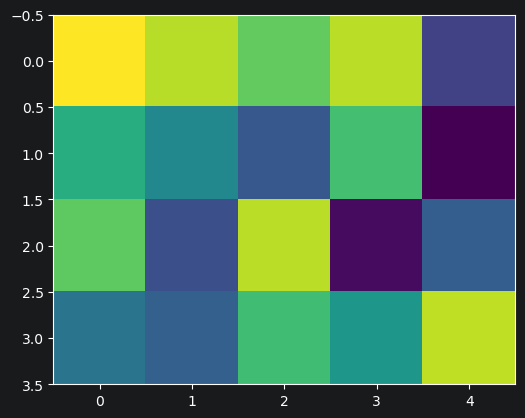

In [9]:
import matplotlib.pyplot as plt

plt.imshow(filter_0)

plt.show()

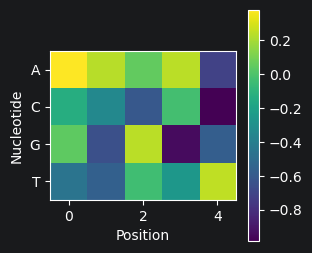

In [10]:
plt.figure(figsize=(3, 3))

plt.imshow(filter_0)

plt.yticks(
    [0, 1, 2, 3],
    ["A", "C", "G", "T"]
)

plt.xlabel("Position")
plt.ylabel("Nucleotide")

plt.colorbar()

plt.show()

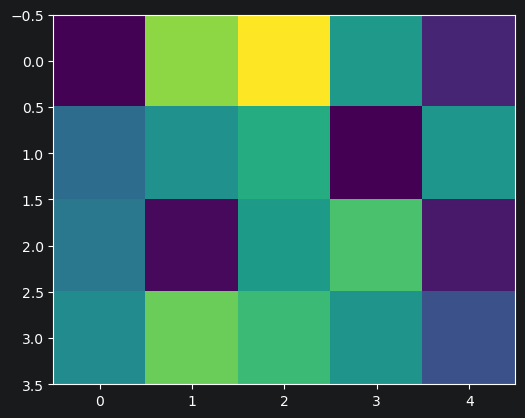

In [1]:
import numpy as np
import matplotlib.pyplot as plt

test = np.random.rand(4, 5)

plt.imshow(test)

plt.show()

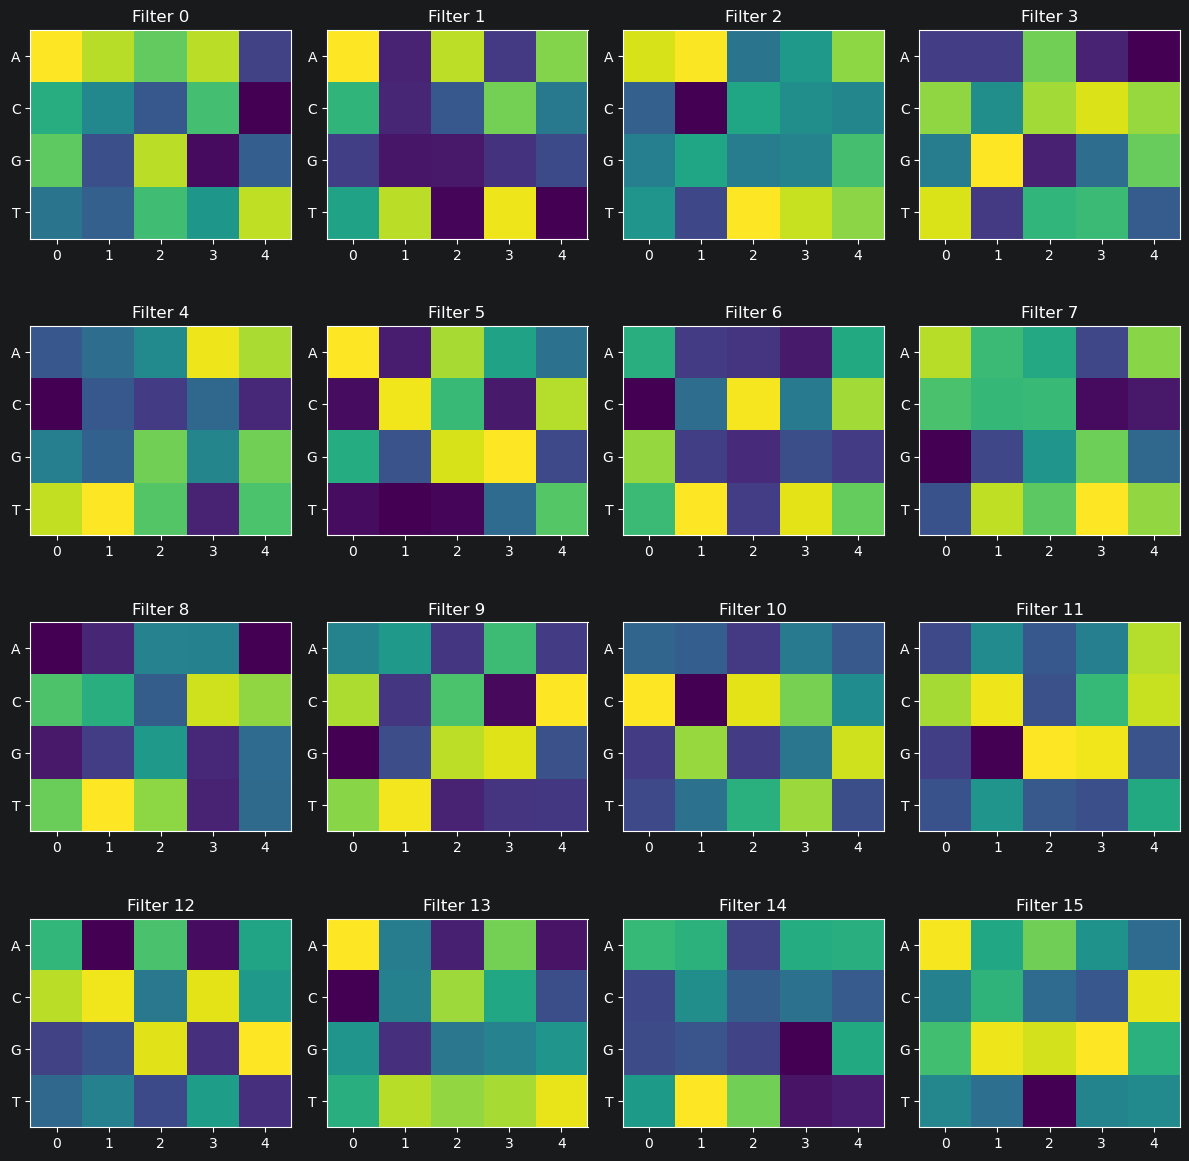

In [11]:
filters_np = (
    model.conv1.weight
    .detach()
    .cpu()
    .numpy()
)

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(filters_np[i])

    ax.set_title(f"Filter {i}")

    ax.set_yticks([0, 1, 2, 3])

    ax.set_yticklabels(
        ["A", "C", "G", "T"]
    )

plt.tight_layout()

plt.show()

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:

plt.imshow(filter_0)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(filter_0)

plt.yticks(
    [0, 1, 2, 3],
    ["A", "C", "G", "T"]
)

plt.xlabel("Position")
plt.ylabel("Nucleotide")

plt.colorbar()

plt.show()